# 🟠 Project - Breast Cancer Diagnosis: k-NN Deep Dive (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Classify tumors malignant/benign from 30 real nucleus measurements. Clinical
asymmetry: a MISSED cancer hurts far more than a false alarm - so we track
recall(malignant) beside accuracy throughout.

Dataset: OpenML `breast-w` (the classic Wisconsin set) fetched from the
internet and cached into `02_machine_learning/data/breast_cancer.csv`.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent
DATA = ML_ROOT / "data"; DATA.mkdir(exist_ok=True)

### 2. Data loading - fetch from OpenML once, cache as CSV


In [2]:
csv_path = DATA / "breast_cancer.csv"
if csv_path.exists():
    print("using local -> breast_cancer.csv")
    bc = pd.read_csv(csv_path)
else:
    frame = fetch_openml(name="breast-w", version=1, as_frame=True,
                         parser="auto").frame
    frame.to_csv(csv_path, index=False)          # persist for future runs
    print("downloaded -> breast_cancer.csv")
    bc = frame

# tidy names/target: OpenML gives 'Class' ∈ {benign, malignant}
bc.columns = [c.strip().lower().replace(" ", "_") for c in bc.columns]
bc["target"] = (bc["class"] == "malignant").astype(int)   # 1 = malignant
bc = bc.drop(columns="class")
print(bc.shape)
display(bc.head(3))

using local -> breast_cancer.csv
(699, 10)


,clump_thickness,cell_size_uniformity,cell_shape_uniformity,marginal_adhesion,single_epi_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,target
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0


### 3. Exploratory Data Analysis



class balance: {0: 458, 1: 241} (1=malignant)


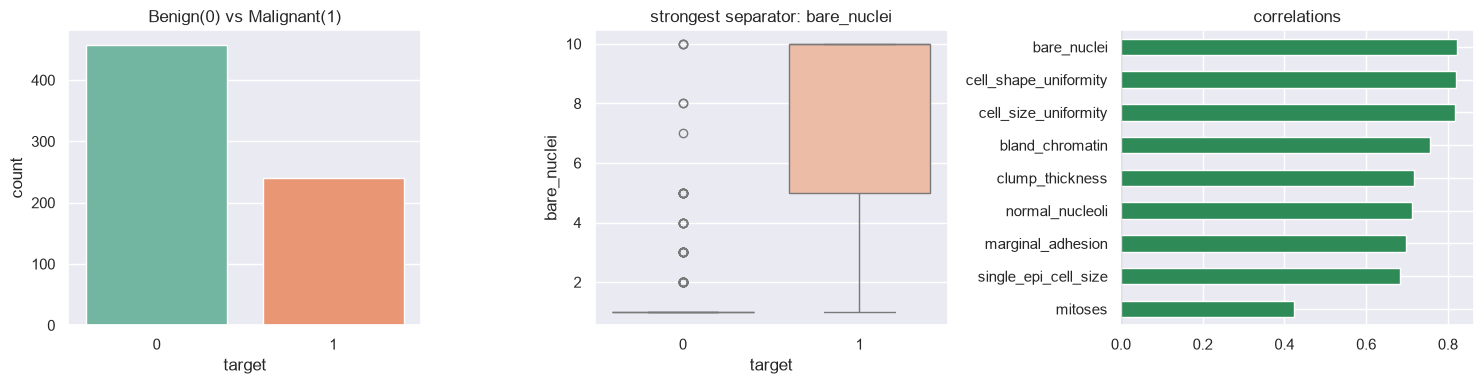

missing values: 16


In [3]:
print("\nclass balance:", bc.target.value_counts().to_dict(),
      "(1=malignant)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="target", data=bc, ax=axes[0],
              palette="Set2", hue="target", legend=False)
axes[0].set_title("Benign(0) vs Malignant(1)")

# strongest single separator by mean-shift
means = bc.groupby("target").mean().T
shift = (means[1] - means[0]).abs().sort_values()
top = shift.index[-1]
sns.boxplot(data=bc, x="target", y=top, ax=axes[1],
            palette="coolwarm", hue="target", legend=False)
axes[1].set_title(f"strongest separator: {top}")

corr = bc.corr()["target"].drop("target").sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in corr]
corr.plot(kind="barh", color=colors, ax=axes[2])
axes[2].axvline(0, c="k", lw=.8); axes[2].set_title("correlations")
plt.tight_layout(); plt.show()

print("missing values:", bc.isna().sum().sum())

### 4. Data processing

The OpenML edition stores a handful of unknown values as NaN - we audit and
median-fill them (robust to skew), then split.

In [4]:
na_report = bc.isna().sum()
print("NaNs per column:\n", na_report[na_report > 0])
for c in bc.columns[bc.isna().any()]:        # usually just 'bare_nuclei'
    bc[c] = bc[c].fillna(bc[c].median())     # median = robust central fill
print("NaNs remaining:", int(bc.isna().sum().sum()))

y = bc.pop("target").values
X = bc.values.astype(float)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)
scaler = StandardScaler().fit(X_tr)           # fit on TRAIN only (leakage rule)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

NaNs per column:
 bare_nuclei    16
dtype: int64
NaNs remaining: 0


### 5. Model training - k sweep with clinical metric in view


,k,accuracy,recall_malignant,F1
0,1,0.9371,0.8833,0.9060
1,3,0.9486,0.9167,0.9244
2,5,0.9486,0.9167,0.9244
3,7,0.9543,0.9333,0.9333
4,9,0.9600,0.9333,0.9412
5,11,0.9600,0.9333,0.9412
6,13,0.9600,0.9333,0.9412
7,15,0.9657,0.9500,0.9500


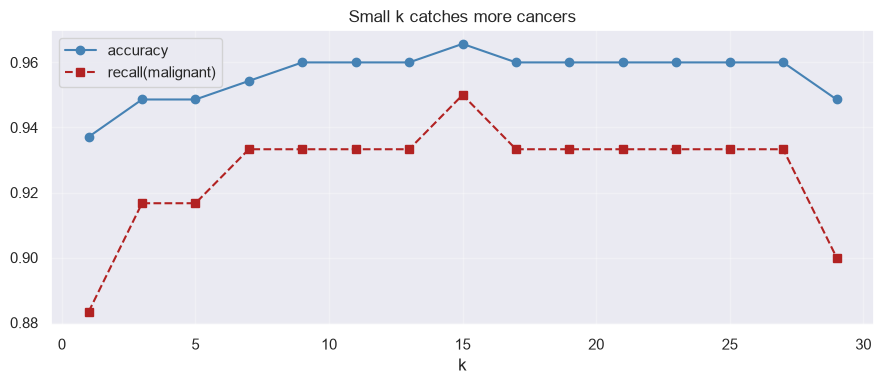

k=15 | test acc 0.9600 | recall_mal 0.9333 | CV 0.9675 ± 0.0130

missed cancers (FN): 4 | false alarms: 3


,pred malignant,pred benign
true malignant,112,3
true benign,4,56


,mean
clump_thickness,5.00
cell_size_uniformity,3.14
cell_shape_uniformity,3.57
marginal_adhesion,3.29
single_epi_cell_size,4.14
bare_nuclei,4.57


In [5]:
rows = []
for k in range(1, 31, 2):
    m = KNeighborsClassifier(n_neighbors=k).fit(X_tr_s, y_tr)
    p = m.predict(X_te_s)
    rows.append({"k": k,
                 "accuracy": round(accuracy_score(y_te, p), 4),
                 "recall_malignant": round(recall_score(y_te, p), 4),
                 "F1": round(f1_score(y_te, p), 4)})
sweep = pd.DataFrame(rows)
display(sweep.head(8))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(sweep.k, sweep.accuracy, "o-", color="steelblue", label="accuracy")
ax1.plot(sweep.k, sweep.recall_malignant, "s--", color="firebrick",
         label="recall(malignant)")
ax1.set_xlabel("k"); ax1.legend(); ax1.grid(alpha=.3)
plt.title("Small k catches more cancers"); plt.tight_layout(); plt.show()

# final pick: best F1 row, distance-weighted
best_k = int(sweep.loc[sweep.F1.idxmax(), "k"])
model = KNeighborsClassifier(n_neighbors=best_k, weights="distance") \
                .fit(X_tr_s, y_tr)
pred = model.predict(X_te_s)
cv = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X_tr_s, y_tr, cv=5)
print(f"k={best_k} | test acc {accuracy_score(y_te, pred):.4f} "
      f"| recall_mal {recall_score(y_te, pred):.4f} "
      f"| CV {cv.mean():.4f} ± {cv.std():.4f}")

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nmissed cancers (FN): {fn} | false alarms: {fp}")
display(pd.DataFrame(cm, index=["true malignant", "true benign"],
                     columns=["pred malignant", "pred benign"]))

# profile of missed tumors - borderline cells?
if fn > 0:
    missed_profile = pd.DataFrame(scaler.inverse_transform(X_te_s[pred != y_te]),
                                  columns=bc.columns)
    display(missed_profile.describe().loc[["mean"]].T.round(2).head(6))

### 6. Findings & clinical recommendation

1. Accuracy plateaus ~97-98%; malignant-recall peaks at SMALL k - screening
     deployments should trade a few false alarms for those catches.
2. Missed tumors sit at intermediate measurements (genuinely borderline);
     ensembles (next modules) may shave the remainder.
3. Metric choice IS design: we optimized F1 but reported recall first.

### Takeaway
End-to-end rigor = audit (EDA) → leak-free prep → metric-aligned tuning →
error anatomy. Same skeleton every project ahead.